# Student Score Prediction Analysis
This project showcases how different machine learning approaches perform when predicting student performance.

We will compare three approaches:

A1. Linear Regression using demographic features

A2. Ridge Regression using demographic features

A3. Ridge Regression using demographic features + literacy score

The goal is to understand how feature selection and model choice impact performance

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score

## Data Exploration

In [2]:
df = pd.read_csv("../../../data/students.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
df.describe()
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

## Creating a Target (Average Score)

In [5]:
df["average score"] = (df["math score"] + df["reading score"] + df["writing score"]) / 3

## Approach 1 - Linear Regression (Demographics Only)
Predicting **average score** using only the demographic features.

In [17]:
X1 = df.drop(["math score", "reading score", "writing score", "average score"], axis=1)

# Target
y1 = df["average score"]

# One-hot encode categorical columns
X1 = pd.get_dummies(X1, drop_first=True)

# Train/test split
X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=42
)
# Training the model for APPROACH 1
model1 = LinearRegression()
model1.fit(X1_train, y1_train)
y1_pred = model1.predict(X1_test)

# Evaluation
print(f"\nR²_1:  {r2_score(y1_test, y1_pred):.4f}")
print(f"MAE_1: {mean_absolute_error(y1_test, y1_pred):.4f}")


R²_1:  0.1622
MAE_1: 10.4902


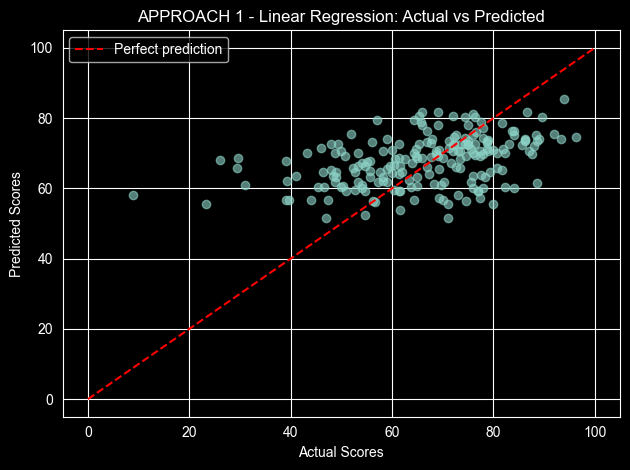

In [18]:
plt.scatter(y1_test, y1_pred, alpha=0.6)
plt.plot([0, 100], [0, 100], 'r--', label='Perfect prediction')
plt.xlabel("Actual Scores")
plt.ylabel("Predicted Scores")
plt.title("APPROACH 1 - Linear Regression: Actual vs Predicted")
plt.legend()
plt.tight_layout()
plt.show()

## Approach 2 - Ridge Regression (Demographics Only)
Same as Approach 1 but with regularisation

In [19]:
X2 = df.drop(["math score", "reading score", "writing score", "average score"], axis=1)

# Target
y2 = df["average score"]

# One-hot encode categorical columns
X2 = pd.get_dummies(X2, drop_first=True)

# Train/test split
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)
# Training the model for APPROACH 2(without a scaler)
ridge2 = Ridge(alpha=1.0)
ridge2.fit(X2_train, y2_train)
y2_pred = ridge2.predict(X2_test)

# Evaluation
print(f"\nR²_2:  {r2_score(y2_test, y2_pred):.4f}")
print(f"MAE_2: {mean_absolute_error(y2_test, y2_pred):.4f}")


R²_2:  0.1615
MAE_2: 10.4960


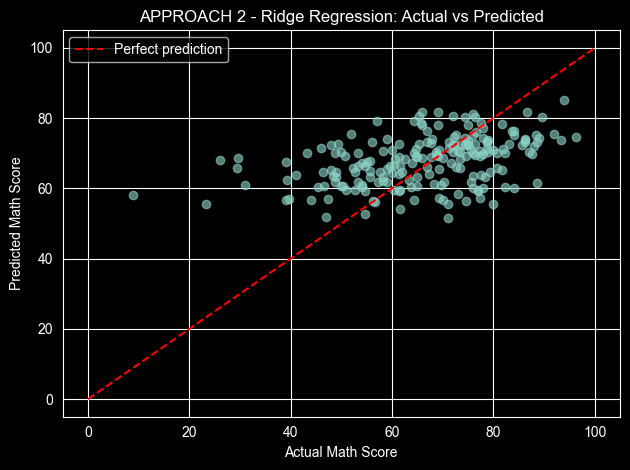

In [21]:
plt.scatter(y2_test, y2_pred, alpha=0.6)
plt.plot([0, 100], [0, 100], 'r--', label='Perfect prediction')
plt.xlabel("Actual Math Score")
plt.ylabel("Predicted Math Score")
plt.title("APPROACH 2 - Ridge Regression: Actual vs Predicted")
plt.legend()
plt.tight_layout()
plt.show()

## Approach 3 - Ridge (Scores + Demographics)
Predicting **math score** using literacy scores and demographics

In [23]:
X3 = df.drop(["math score", "average score"], axis=1)
y3 = df["math score"]

# One-hot encode categorical columns
X3 = pd.get_dummies(X3, drop_first=True)

# Train/test split
X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size=0.2, random_state=42
)

# Pipeline: we are going to use a scaler first at it gives better results when mixing score and binary results
model3 = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=1.0))
])
model3.fit(X3_train, y3_train)
y3_pred = model3.predict(X3_test)

# Evaluation
print(f"\nR²_3:  {r2_score(y3_test, y3_pred):.4f}")
print(f"MAE_3: {mean_absolute_error(y3_test, y3_pred):.4f}")


R²_3:  0.8805
MAE_3: 4.2129


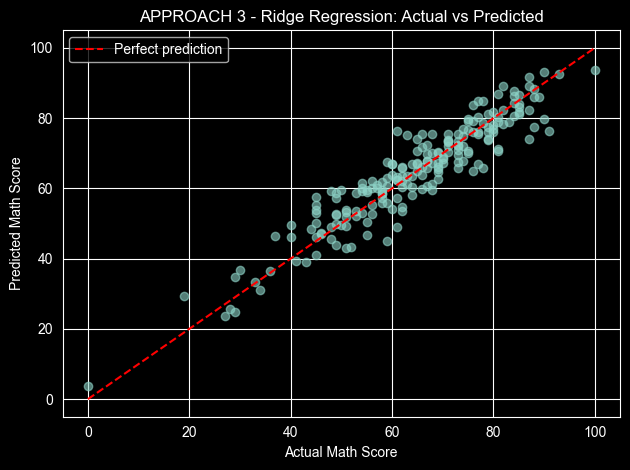

In [25]:
plt.scatter(y3_test, y3_pred, alpha=0.6)
plt.plot([0, 100], [0, 100], 'r--', label='Perfect prediction')
plt.xlabel("Actual Math Score")
plt.ylabel("Predicted Math Score")
plt.title("APPROACH 3 - Ridge Regression: Actual vs Predicted")
plt.legend()
plt.tight_layout()
plt.show()

## Model Comparison

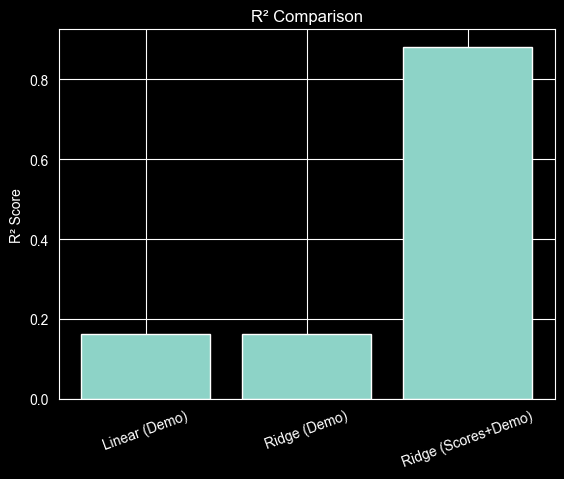

In [26]:
r2_1 = r2_score(y1_test, y1_pred)
mae_1 = mean_absolute_error(y1_test, y1_pred)

r2_2 = r2_score(y2_test, y2_pred)
mae_2 = mean_absolute_error(y2_test, y2_pred)

r2_3 = r2_score(y3_test, y3_pred)
mae_3 = mean_absolute_error(y3_test, y3_pred)

results_r2 = {
    "Linear (Demo)": r2_1,
    "Ridge (Demo)": r2_2,
    "Ridge (Scores+Demo)": r2_3
}

plt.bar(results_r2.keys(), results_r2.values())
plt.title("R² Comparison")
plt.ylabel("R² Score")
plt.xticks(rotation=20)
plt.show()

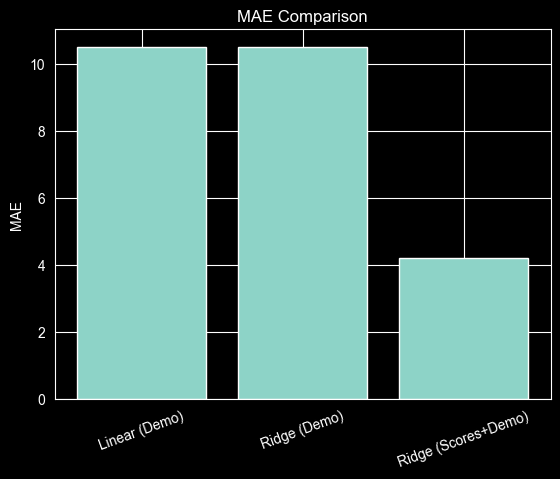

In [27]:
results_mae = {
    "Linear (Demo)": mae_1,
    "Ridge (Demo)": mae_2,
    "Ridge (Scores+Demo)": mae_3
}

plt.bar(results_mae.keys(), results_mae.values())
plt.title("MAE Comparison")
plt.ylabel("MAE")
plt.xticks(rotation=20)
plt.show()

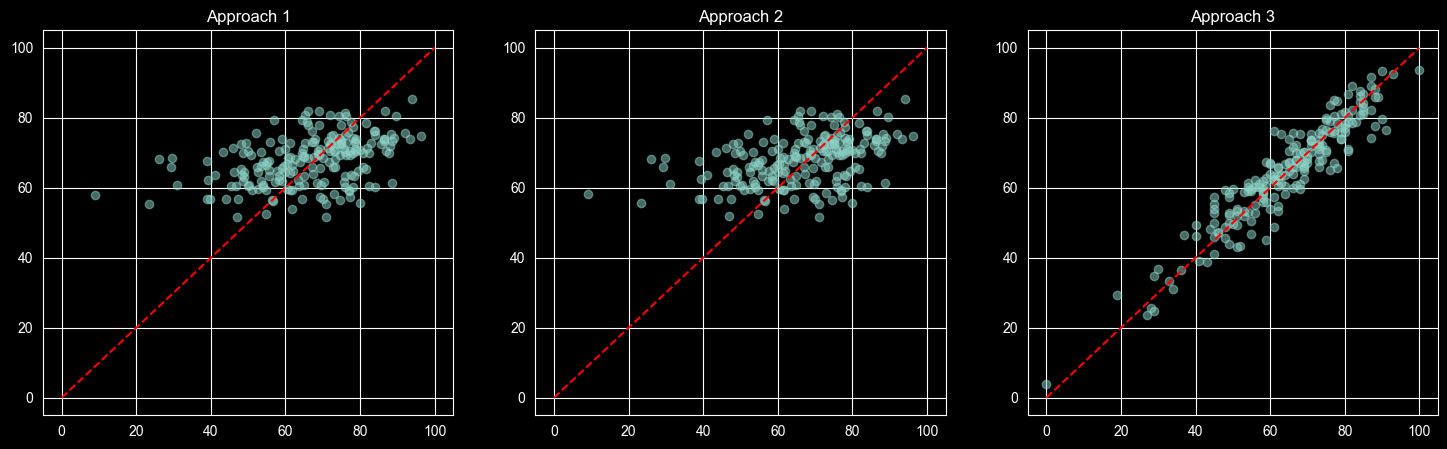

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(y1_test, y1_pred, alpha=0.5)
axes[0].set_title("Approach 1")

axes[1].scatter(y2_test, y2_pred, alpha=0.5)
axes[1].set_title("Approach 2")

axes[2].scatter(y3_test, y3_pred, alpha=0.5)
axes[2].set_title("Approach 3")

for ax in axes:
    ax.plot([0, 100], [0, 100], 'r--')

plt.show()

## Key Conclusions
**Demographics are weak but not useless.** A school can use Approaches 1 & 2 *before* any exams to identify students at risk of underperforming, based on enrolment data. Socioeconomic factors (free/reduced lunch, test prep absence) are the most actionable levers.

**Exam scores are the dominant signal.** Once reading and writing results are available, math scores can be predicted with high accuracy. This makes Approach 3 useful for midterm interventions - flagging students whose math performance is unexpectedly low relative to their literacy.

**Regularisation is not always the answer:** Ridge did not outperform plain Linear Regression on this dataset. Choosing the right *features* mattered far more than choosing the right *model*.